In [51]:
######################################## CREATE AND READ JSON HANDLER ########################################

# Import and create the handler
from json_handler import JSONHandler

# Case 0: DEFAULT inside the folder
handler = JSONHandler("./losses_log.json")

# # Case 1: DYNAle/cMIC vox
# handler = JSONHandler(
#     "/home/micheode/Presentation_results/PPillars_Checkpoints/PPillars_DynamicVox/losses_log_cut_to_80.json")

# # Case 2: HARD vox
# handler = JSONHandler(
#     "/home/michele/code/Presentation_results/PPillars_Checkpoints/PPillars_HardVox/losses_log.json")

# # Case 3: CONE-SHAPED --> DYNAMIC vox
# handler = JSONHandler(
#     "/home/michele/code/Presentation_results/PPillars_Checkpoints/Cone-Shaped_DynamicVox/losses_log.json")

# # Case 4: CONE-AUGMENTED --> DYNAMIC vox
# handler = JSONHandler(
#     "/home/michele/code/Presentation_results/PPillars_Checkpoints/Cone-Augmented_DynamicVox/losses_log.json")

# Case 5: CONE-AUGMENTED --> HARD vox
handler = JSONHandler(
    "/home/michele/code/Presentation_results/PPillars_Checkpoints/Cone-Augmented_HardVox/losses_log.json")

# # Case 6: MVX-Net with STD Convolution
# handler = JSONHandler(
#     "/home/michele/code/michele_mmdet3d/data/TrainingSafeCopies/MVX_SmallVoxels_StdConvolution/losses_log_MVX_SmallVoxels_StdConvolution.json")

# Read the file
dictionary_list = handler.read_json_file()
print(f"The file has the following number of elements:\n\t{len(dictionary_list)}")

The file has the following number of elements:
	240


In [52]:
######################################## PROCESS THE RAW DATA ########################################

# Create a list where to store all the dictionaries for the final plotting
final_dict_list = []
# Create two temporary variables where to store the losses of the training
temp_loss = 0
temp_counter = 0
# For cycle for the processing of data
for i in range(len(dictionary_list)):
    # When the element is of type "training", update the temporary variables (data is cumulative)
    if dictionary_list[i]['type'] == "training":
        # Else, just update the temporary variables
        temp_loss += dictionary_list[i]['total_loss']
        temp_counter += 1
    # When the element is "validation", finalize the storage of training data and store the validation data
    else:
        final_dict_list.append(
            {'type': "training",
            'loss': (temp_loss/temp_counter)}
        )
        temp_loss=0
        temp_counter=0
        final_dict_list.append(
            {'type': "validation",
             'loss': dictionary_list[i]['total_loss'],
             'ap40': dictionary_list[i]['ap40'],
             'ap40_reduced_array': dictionary_list[i]['ap40_reduced_array'],
             'reduced_x_limit_array': dictionary_list[i]['reduced_x_limit_array'],
             'ap40_iou_thr_list': dictionary_list[i]['ap40_iou_thr_list'],
             'precisions_list': dictionary_list[i]['precisions_list'],
             'recalls_list': dictionary_list[i]['recalls_list'],
             'precisions_reduced_array': dictionary_list[i]['precisions_reduced_array'],
             'recalls_reduced_array': dictionary_list[i]['recalls_reduced_array']
             }
        )



for element in final_dict_list:
    print(element)

{'type': 'training', 'loss': 0.9445902298400966}
{'type': 'validation', 'loss': 0.7368937459005608, 'ap40': 0.6932005332915068, 'ap40_reduced_array': [0.8281309237962842, 0.7989263624693658, 0.7668672790624012, 0.7435596042707413, 0.7383855981416958, 0.7296987087517939, 0.7268483231707317, 0.7240201195786282, 0.7240201195786282, 0.39634146341463417, 0.4634146341463417, 0.38753387533875344, 0.32520325203252043, 0.0, 0.0, 0.0, 0.0], 'reduced_x_limit_array': [[0, 70], [0, 80], [0, 90], [0, 100], [0, 110], [0, 120], [0, 130], [0, 140], [0, 150], [70, 80], [80, 90], [90, 100], [100, 110], [110, 120], [120, 130], [130, 140], [140, 150]], 'ap40_iou_thr_list': [0.1, 0.125, 0.15000000000000002, 0.17500000000000002, 0.2, 0.225, 0.25, 0.275, 0.30000000000000004, 0.325, 0.35, 0.375, 0.4, 0.42500000000000004, 0.45000000000000007, 0.475, 0.5, 0.525, 0.55, 0.5750000000000001, 0.6, 0.625, 0.65, 0.675, 0.7000000000000001, 0.725, 0.75, 0.775, 0.8, 0.8250000000000001, 0.85, 0.875, 0.9], 'precisions_list'

In [53]:
# Establish the reduced_x_limit values
reduced_x_limit_array = final_dict_list[1]['reduced_x_limit_array']
print("\nList of the possible ranges (right), with the associated index (left)")
for i, element in enumerate(reduced_x_limit_array):
    print(f"{i}:\t{element}")

# Choose which reduced values to choose
list_of_reductions_to_show = [
    0,
    9,
    10, 
    11,
]


List of the possible ranges (right), with the associated index (left)
0:	[0, 70]
1:	[0, 80]
2:	[0, 90]
3:	[0, 100]
4:	[0, 110]
5:	[0, 120]
6:	[0, 130]
7:	[0, 140]
8:	[0, 150]
9:	[70, 80]
10:	[80, 90]
11:	[90, 100]
12:	[100, 110]
13:	[110, 120]
14:	[120, 130]
15:	[130, 140]
16:	[140, 150]


AP total:
	96.37841832963787
AP in [0, 70]:
	100.0
AP in [0, 80]:
	92.98780487804876
AP in [0, 90]:
	80.48780487804876
AP in [0, 100]:
	97.56097560975608


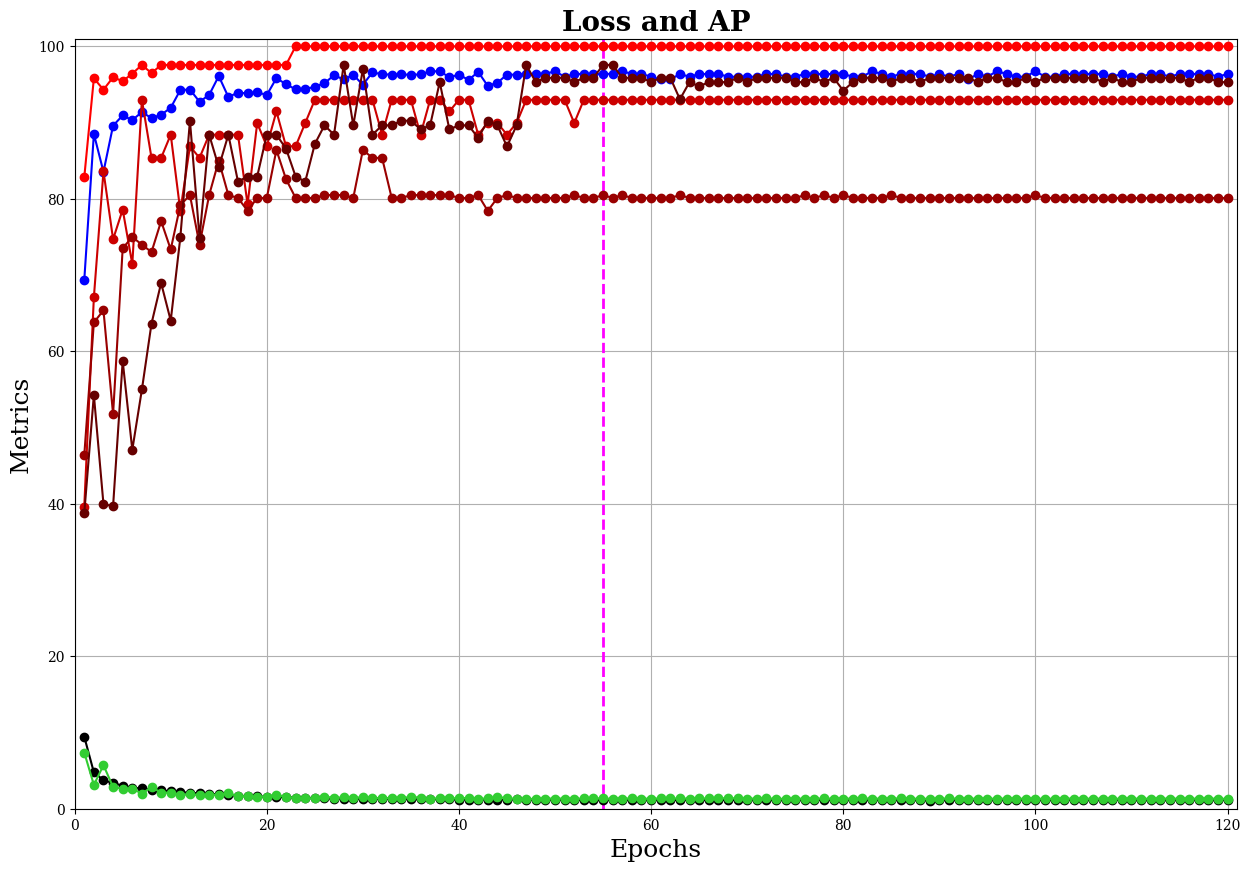

In [54]:
######################################## PLOT THE LOSSES AND METRICS ########################################

import numpy
from plotters import *

# Define the validation interval
val_interval = 1

# AP40 multiplier ----------------> Needed if want to visualize AP40 in [0:100%] rather than [0:1]
ap40_multiplier = 100
loss_multiplier = 10

# Separate the data into lists
training_losses = [entry['loss']*loss_multiplier for entry in final_dict_list if entry['type'] == 'training']
validation_losses = [entry['loss']*loss_multiplier for entry in final_dict_list if entry['type'] == 'validation']
metric_ap40 = [entry['ap40']*ap40_multiplier for entry in final_dict_list if entry['type'] == 'validation']
# Special computations for the reduced AP40
metric_ap40_reduced_array = []
for entry in final_dict_list:
    if entry['type'] == 'validation':
        final_list_of_lists = []
        for sublist in entry['ap40_reduced_array']:
            final_list_of_lists.append(sublist * ap40_multiplier)
        metric_ap40_reduced_array.append(final_list_of_lists)

# Create a range of indices for the X axis
epochs = numpy.linspace(val_interval, (len(training_losses))*val_interval, len(training_losses))

plot_losses_metrics(epochs, training_losses, validation_losses, metric_ap40, metric_ap40_reduced_array, reduced_x_limit_array, 
                    list_of_reductions_shown=list_of_reductions_to_show, 
                    top_y_lim=101, x_lim=(0, 121),
                    wanna_annotate=False, best_epoch=55)

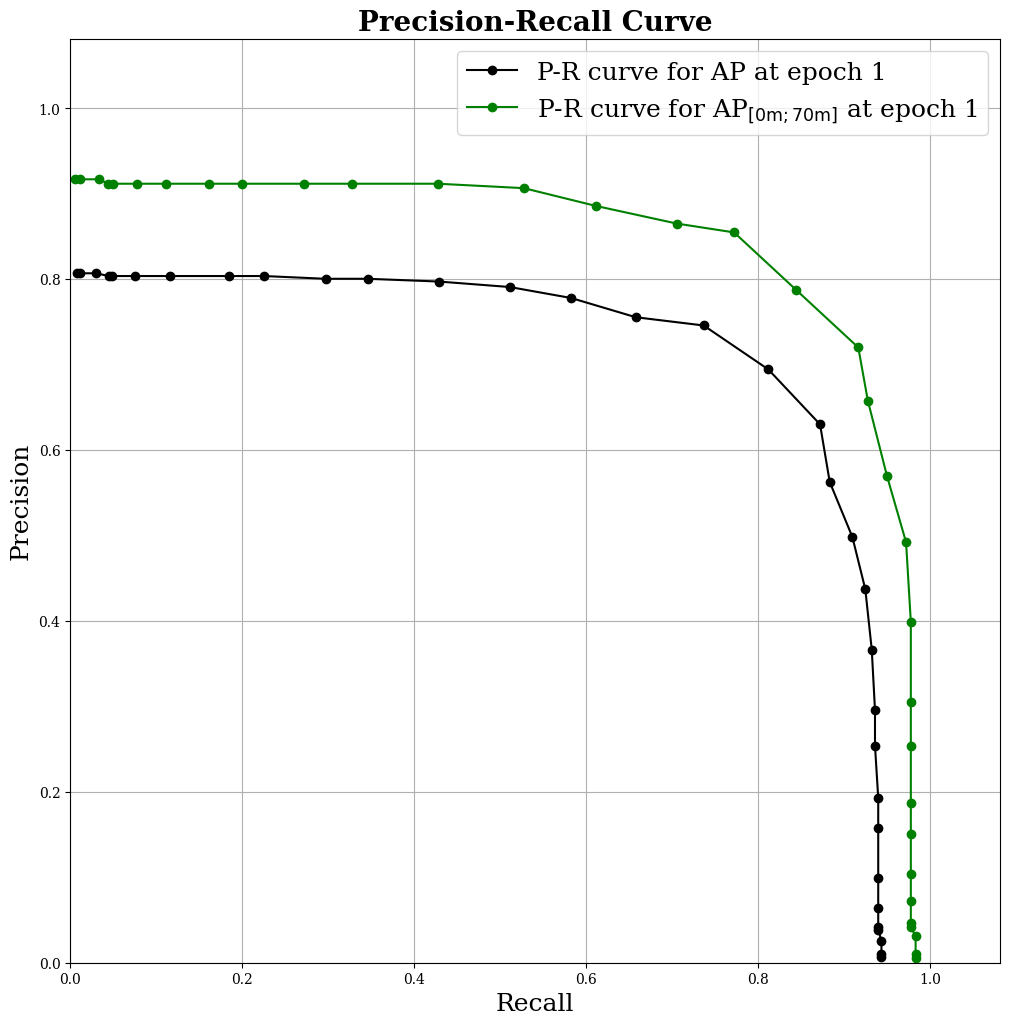

In [55]:
# Select the epoch for which the PR-curve must be visualized
pr_curve_epoch = 1

# Compute the corresponding index
i = int(pr_curve_epoch/val_interval)*2-1
# Get the corresponding data
precisions = final_dict_list[i]['precisions_list']
recalls = final_dict_list[i]['recalls_list']
precisions_reduced = final_dict_list[i]['precisions_reduced_array'][0]
recalls_reduced = final_dict_list[i]['recalls_reduced_array'][0]
iou_thr_list = final_dict_list[i]['ap40_iou_thr_list']

# Plot the PR-curve
plot_precision_recall_curve(pr_curve_epoch, precisions, recalls, precisions_reduced, recalls_reduced, iou_thr_list, wanna_annotate=False)